In [1]:
# Operate from the parent directory
# This allows us to import modules from the parent directory
import os
os.chdir("..")

import torch
from torch.utils.data import DataLoader
from pose_encoder.advanced_pose_encoder import AdvancedPoseEncoder
from pose_encoder.advanced_pose_encoder_training_loop import train_advanced_encoder
import utils.utils as utils
from dataset.dataset import *

device = utils.get_device()

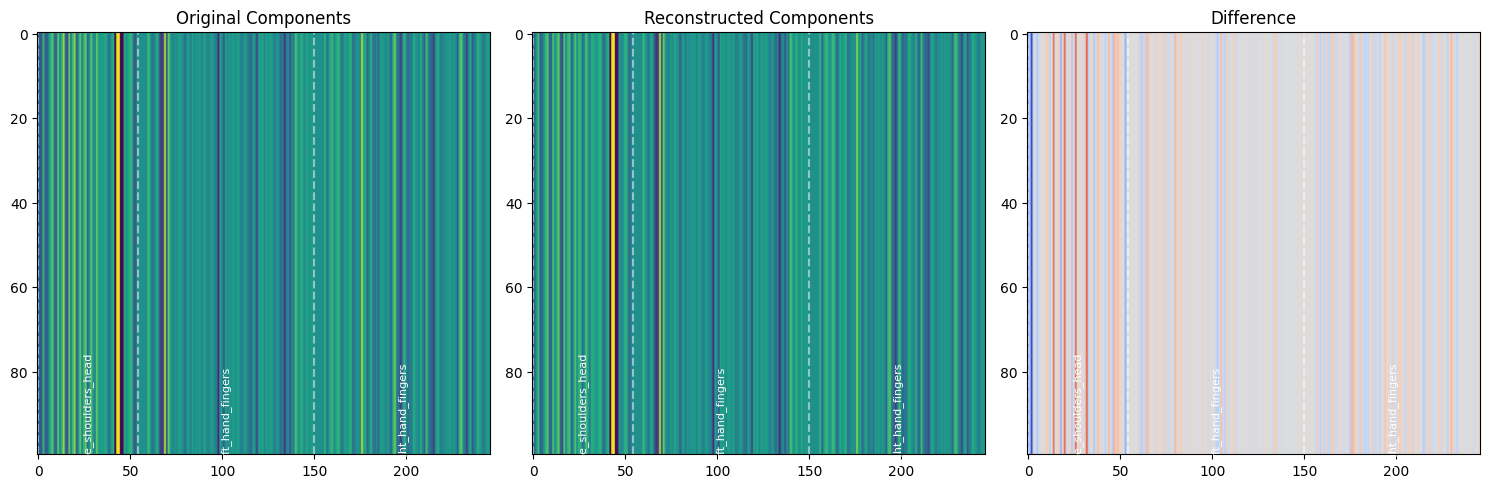

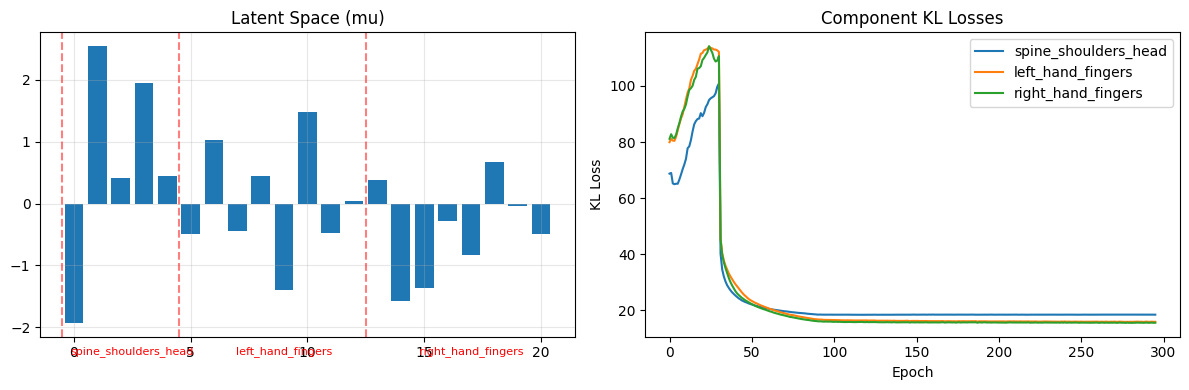

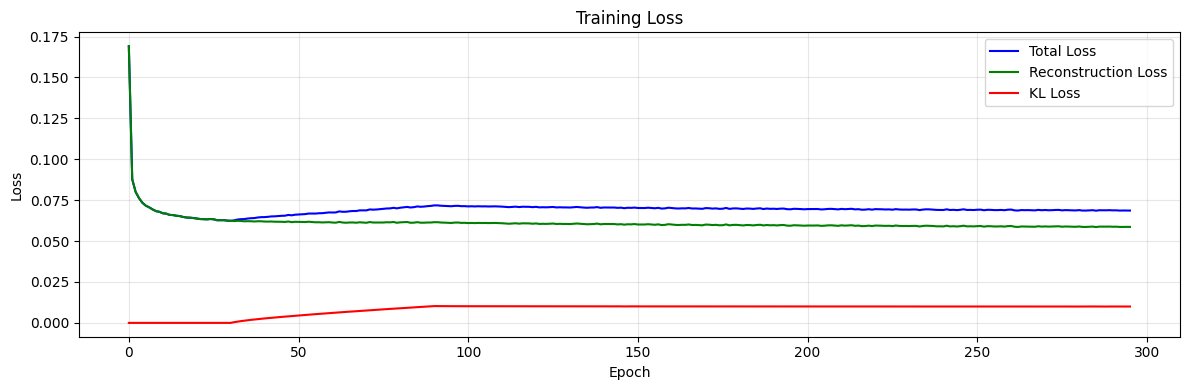

Epoch 300/300: 100%|██████████| 1024/1024 [00:05<00:00, 171.86it/s, Loss=0.0678, Recon=0.0574, KL=0.010397, Active=21/21]


Model saved to pose_encoder/models/advanced_pose_encoder_64.pth


AdvancedPoseEncoder(
  (encoders): ModuleDict(
    (spine_shoulders_head): SimpleEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=54, out_features=54, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=54, out_features=27, bias=True)
        (3): GELU(approximate='none')
      )
      (mu): Linear(in_features=27, out_features=5, bias=True)
      (logvar): Linear(in_features=27, out_features=5, bias=True)
      (decoder): Sequential(
        (0): Linear(in_features=5, out_features=27, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=27, out_features=54, bias=True)
        (3): GELU(approximate='none')
        (4): Linear(in_features=54, out_features=54, bias=True)
      )
    )
    (left_hand_fingers): SimpleEncoder(
      (encoder): Sequential(
        (0): Linear(in_features=96, out_features=96, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=96, out_features=48, bias=Tr

In [2]:
dataset = GPUDataset(
    consolidated_file = "dataset/genea2023_dataset/trn/main-agent/consolidated.npz",
    seq_length = 1, # 1 because we are extracting poses, i.e. single frames
    batch_size = 256,
    epoch_length = 1024,
    device = device
)

train_advanced_encoder(
    model_name="advanced_pose_encoder_64",
    model = AdvancedPoseEncoder(
        pose_dim=345,
        component_definitions = {
            # Preserved (no encoding/decoding)
            'world_pos': {
                'bone_names': ['body_world'],
                'type': 'preserve',
                'use_position': True
            },
            'left_hand_rot': {
                'bone_name': 'b_l_wrist',
                'type': 'world_preserve_after_ik'
            },
            'right_hand_rot': {
                'bone_name': 'b_r_wrist',
                'type': 'world_preserve_after_ik'
            },
            'left_foot_rot': {
                'bone_name': 'b_l_foot',
                'type': 'world_preserve_after_ik'
            },
            'right_foot_rot': {
                'bone_name': 'b_r_foot',
                'type': 'world_preserve_after_ik'
            },
            # Auto-encoded components - explicit bone lists
            'spine_shoulders_head': {
                'bone_names': [
                    'b_root', 'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3',
                    'b_l_shoulder', 'b_r_shoulder', 'b_neck0', 'b_head'
                ],
                'type': 'encode',
                'z_dim': 5
            },
            'left_hand_fingers': {
                'bone_names': [
                    # Left thumb
                    'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3',
                    # Left fingers  
                    'b_l_index1', 'b_l_index2', 'b_l_index3',
                    'b_l_middle1', 'b_l_middle2', 'b_l_middle3',
                    'b_l_ring1', 'b_l_ring2', 'b_l_ring3',
                    'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3'
                ],
                'type': 'encode',
                'z_dim': 8
            },
            'right_hand_fingers': {
                'bone_names': [
                    # Right thumb
                    'b_r_thumb0', 'b_r_thumb1', 'b_r_thumb2', 'b_r_thumb3',
                    # Right fingers
                    'b_r_index1', 'b_r_index2', 'b_r_index3',
                    'b_r_middle1', 'b_r_middle2', 'b_r_middle3',
                    'b_r_ring1', 'b_r_ring2', 'b_r_ring3',
                    'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3'
                ],
                'type': 'encode',
                'z_dim': 8
            },
            # IK components - using skeleton's enhanced chain info
            'left_arm_ik': {
                'type': 'ik',
                'chain_joints': ['b_l_arm', 'b_l_forearm'],
                'end_effector': 'b_l_wrist',
                'z_dim': 4,  # 3 for target position + 1 swivel rotation
                'twist_joint': 'b_l_arm_twist',
                'chain_parent': 'b_l_shoulder',
                'bone1_forward_dir': [0.9993694424629211, -0.023177823051810265, -0.026897454634308815],
                'bone1_up_dir': [-0.02316943369805813, -0.9997313618659973, 0.0006235920009203255],
                'bone2_forward_dir': [0.9993695020675659, -0.02317732758820057, -0.026897458359599113],
                'bone2_up_dir': [-0.023168936371803284, -0.9997313618659973, 0.0006235786713659763],
            },
            'right_arm_ik': {
                'type': 'ik',
                'chain_joints': ['b_r_arm', 'b_r_forearm'],
                'end_effector': 'b_r_wrist',
                'z_dim': 4,
                'twist_joint': 'b_r_arm_twist',
                'chain_parent': 'b_r_shoulder',
                'bone1_forward_dir': [-0.9992618560791016, -0.028031472116708755, -0.026267891749739647],
                'bone1_up_dir': [0.02802179381251335, -0.9996070861816406, 0.0007366171339526772],
                'bone2_forward_dir': [-0.9992617964744568, -0.028031865134835243, -0.02626790478825569],
                'bone2_up_dir': [0.02802218683063984, -0.9996070265769958, 0.0007366279023699462],
            },
            'left_leg_ik': {
                'type': 'ik',
                'chain_joints': ['b_l_upleg', 'b_l_leg'],
                'end_effector': 'b_l_foot',
                'z_dim': 4,
                'chain_parent': 'b_root',
                'bone1_forward_dir': [0.0, -0.9999752044677734, 0.007038275245577097],
                'bone1_up_dir': [0.0, 0.007038275711238384, 0.9999752640724182],
                'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420658826828],
                'bone2_up_dir': [0.0, 0.0801420658826828, -0.996783435344696],
            },
            'right_leg_ik': {
                'type': 'ik',
                'chain_joints': ['b_r_upleg', 'b_r_leg'],
                'end_effector': 'b_r_foot',
                'z_dim': 4,
                'chain_parent': 'b_root',
                'bone1_forward_dir': [0.0, -0.9999904632568359, 0.004357356112450361],
                'bone1_up_dir': [0.0, 0.0043573565781116486, 0.9999905228614807],
                'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420733332634],
                'bone2_up_dir': [0.0, 0.0801420733332634, -0.996783435344696],
            }
        },
        skeleton = dataset.skeleton,
        device = utils.get_device()
    ),
    pose_training_loader = DataLoader(
        dataset = dataset,
        batch_size = 1,
        num_workers = 0,
        pin_memory = False
    ),
    num_epochs = 300,
    warm_up_kl_anneal_steps = 30,
    kl_anneal_steps = 60,
    kl_beta = 0.0002,
    visualize_steps = 5,
    device = device
)